# Library

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statistics as st

from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.tsa.holtwinters import ExponentialSmoothing as es
from statsmodels.graphics.tsaplots import plot_pacf as pacf, plot_acf as acf
from prophet import Prophet


import re
import copy
import plotly.graph_objects as go
import plotly.offline as py
import warnings
warnings.filterwarnings('ignore')

from pandas.plotting import autocorrelation_plot as acp

from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse

from statsmodels.tsa.api import VAR


# Data

In [2]:

# Data
data = pd.read_csv(r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 7 Time Series Analysis\Resources\drive-download-20260225T095330Z-1-001\Project 3 - Holts Winter\demand.csv")
df = copy.deepcopy(data)

### 1. EDA

In [3]:
# Information---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
print(df.info(), '--'*60)

# Check and Fill Null Values---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Null_Values = df.isna().sum()
print(Null_Values, '--'*60)


# Fill Missing Value of Same Sku Above and below Mean---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 2. Apply linear interpolation within each group---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# df[(df['sku_id'] == 245338) & (df['store_id'] == 9436) & (df['is_featured_sku'] == 0) & (df['is_display_sku'] == 0)]
# Define the columns to group by
group_cols = ['sku_id', 'store_id', 'is_featured_sku', 'is_display_sku']

# Apply linear interpolation strictly to the 'total_price' column---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
df['total_price'] = df.groupby(group_cols)['total_price'].transform(lambda x: x.interpolate(method='linear'))
print('After Imputation Null Values :\n', df.isna().sum(), '--'*50)

# Plot How  Much Discount Is Given---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
df['Discount'] = df['base_price'] - df['total_price']
df['Discount_pct'] = round(((df['base_price'] - df['total_price'])/df['total_price'])*100, 3)

# Total Store---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Total_Stores = len(df['store_id']) - df['store_id'].duplicated().sum()
# Total_Stores = df['store_id'].nunique()
Total_Stores = df['store_id'].nunique()
print('Total Stores : ', Total_Stores, '--'*60)

# Total SKU(Stock Keeping Units)---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Total_SKU = df['sku_id'].nunique()
print('Total SKU :', Total_SKU, '--'*60)

# Total Sales---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Total_Sales = sum(df['total_price'] * df['units_sold'])
print('Total Sales :', re.sub(r'(\d)(?=(\d{2})*\d{3}\.)', r'\1,', f"₹{Total_Sales:.2f}"), '--'*60)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB
None ------------------------------------------------------------------------------------------------------------------------
record_ID          0
week               0
store_id           0
sku_id             0
total_price        1
base_price         0
is_featured_sku    0
is_display_sku     0
units_sold      

In [4]:
df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,Discount,Discount_pct
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20,12.825,12.95
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28,0.000,0.00
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19,0.000,0.00
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44,0.000,0.00
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52,0.000,0.00


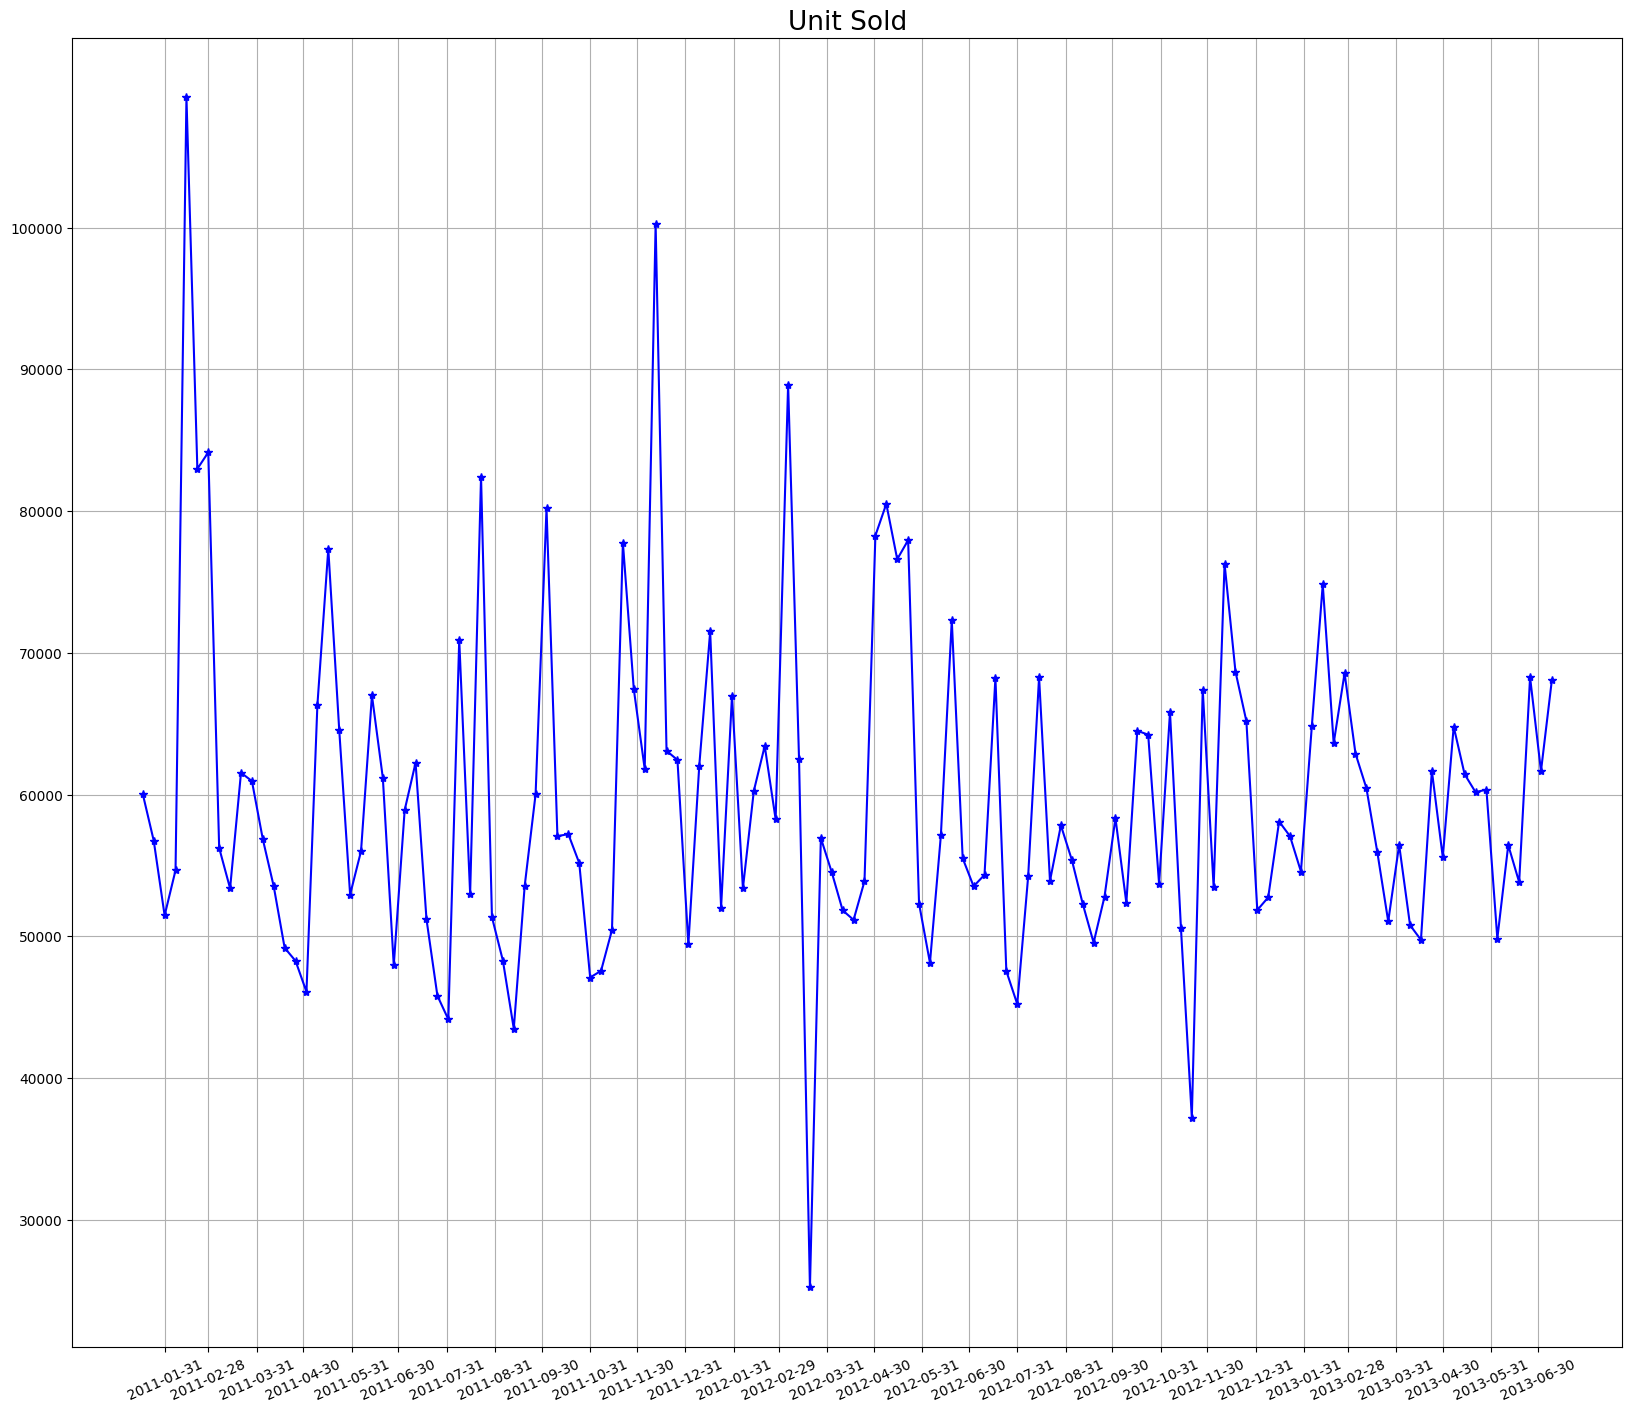

In [5]:
# Converting Week Columns to Date time 
df['week'] = pd.to_datetime(df['week'], format='%d/%m/%y')

# Aggrigating the Day by Week
week_data = df.groupby('week')['units_sold'].sum().reset_index()

# Plot Unit Sold
plt.figure(figsize=(20, 17))
plt.plot(week_data['week'], week_data['units_sold'], color='blue', marker='*')
plt.yticks(np.arange(30000, 110000, 10000))
plt.xticks(pd.date_range(start=df['week'].min(), end=df['week'].max(), freq='1ME'), rotation=24)
plt.title('Unit Sold', fontsize=19)
plt.grid()
plt.show();

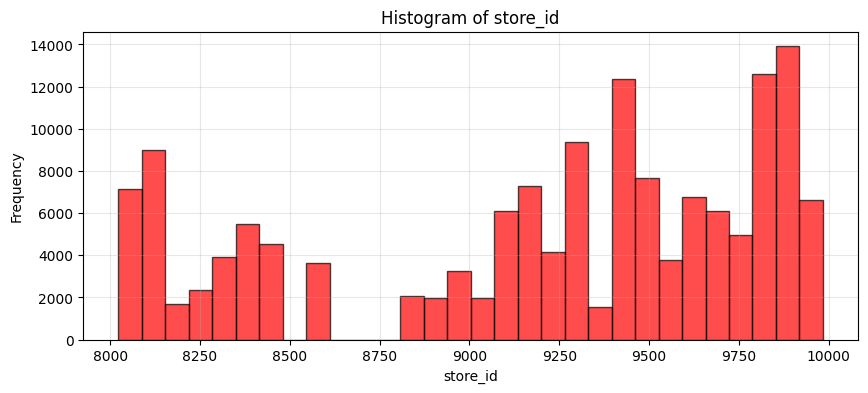

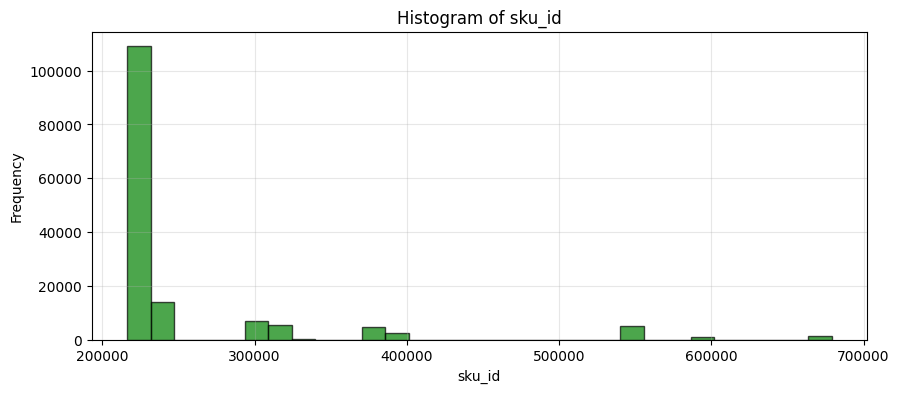

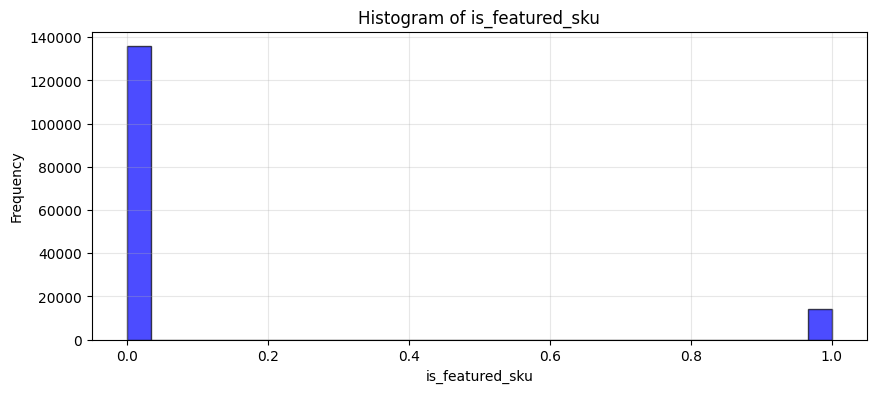

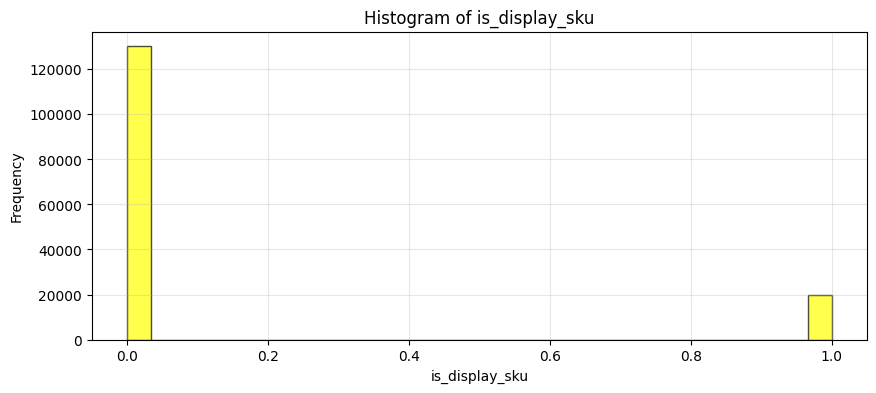

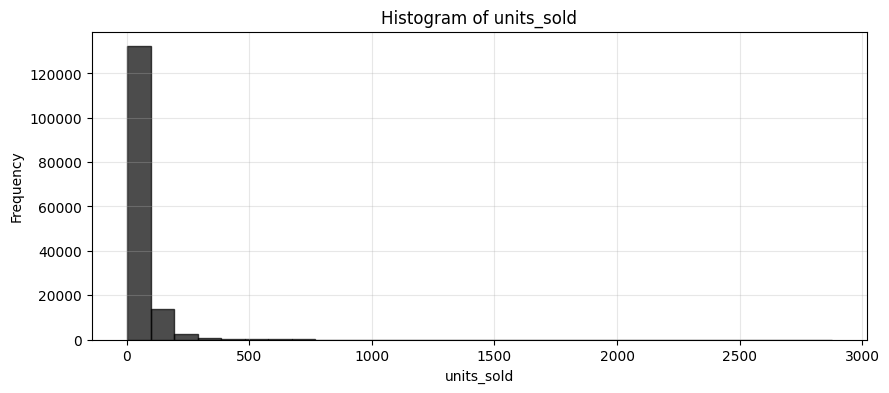

In [6]:
# Plot Histogram For Target Values
cat_col = ['store_id', 'sku_id', 'is_featured_sku', 'is_display_sku', 'units_sold']
color = ['red', 'green', 'blue', 'yellow', 'black']

# Plot Distribution by Histogram
for no, col in enumerate(cat_col):
    plt.figure(figsize=(10,4))
    plt.hist(df[col], bins=30, color=color[no], alpha=0.7, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.show()

--- total_price ---
High Outliers  : 12029 | 8.01%
Lower Outliers : 0 | 0.00%



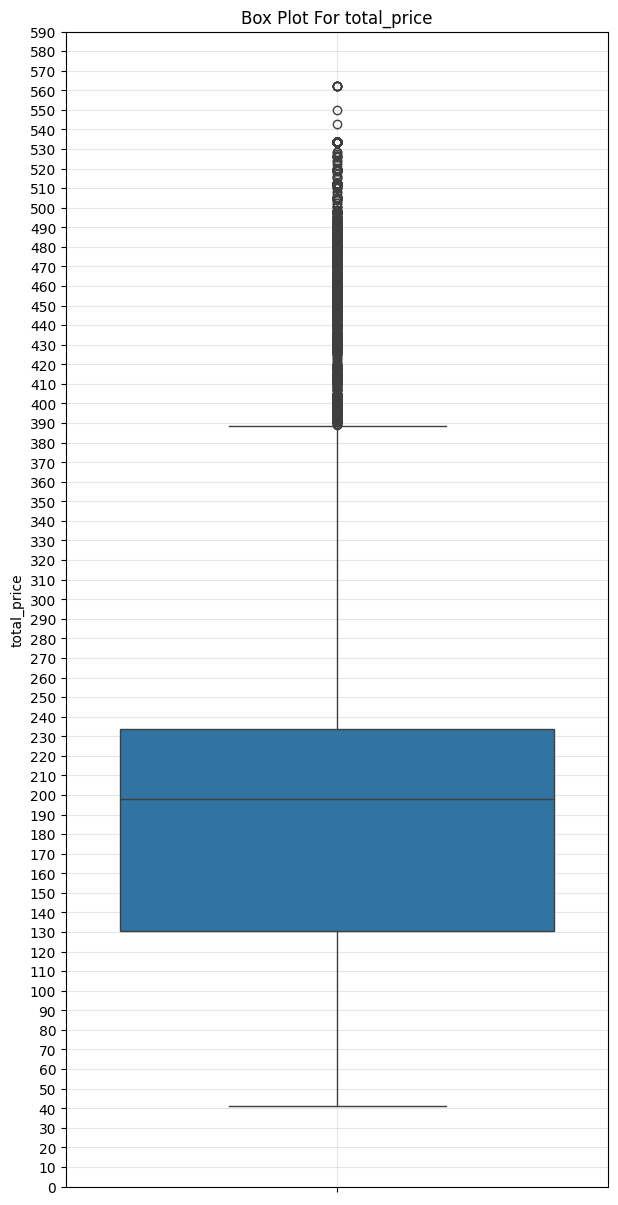

--- base_price ---
High Outliers  : 17123 | 11.40%
Lower Outliers : 0 | 0.00%



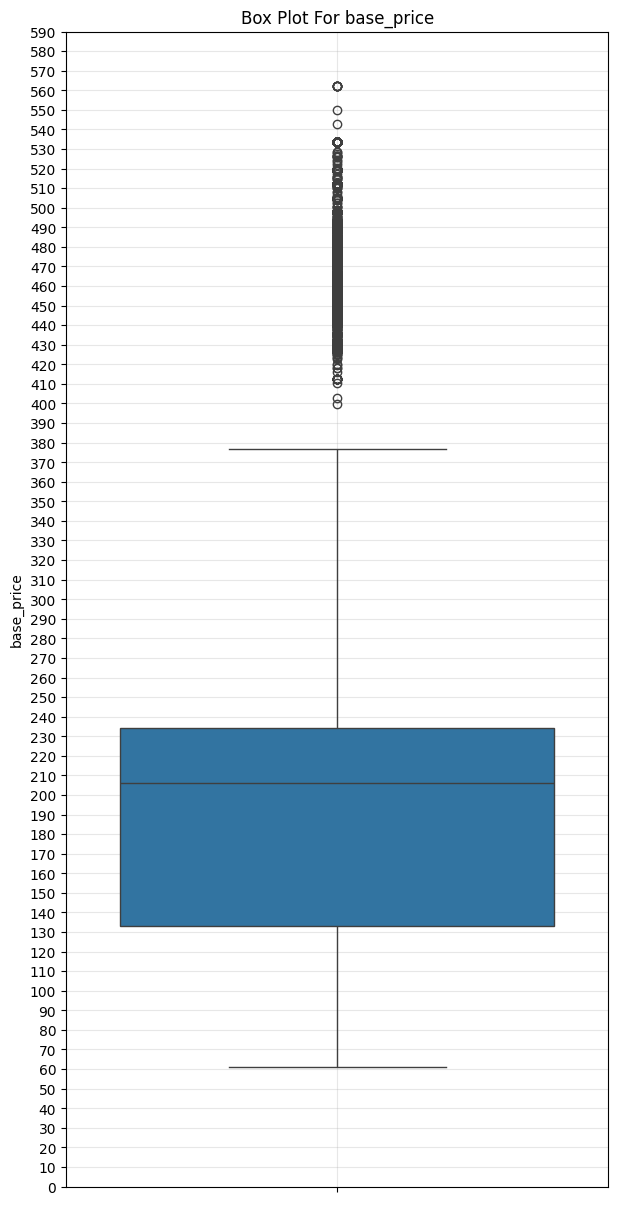

<Axes: >

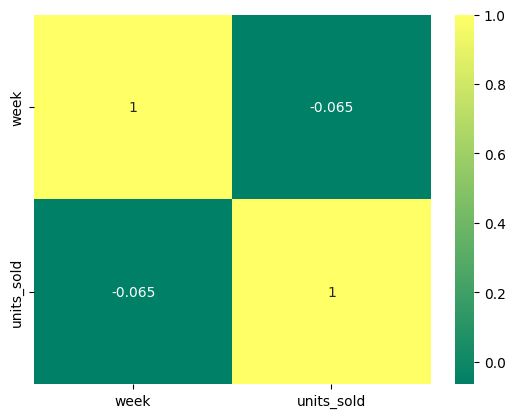

In [7]:
# Box Plot, Outlier Detection and Correlation
num_col = ['total_price', 'base_price']

for no, col in enumerate(num_col):
    # 1. Use the dynamic 'col' variable for quantiles
    q1, q3 = df[col].quantile([0.25, 0.75])
    IQR = q3 - q1
    
    lower_range = q1 - 1.5 * IQR   
    upper_range = q3 + 1.5 * IQR

    # 2. Calculate outlier counts (these are integers)
    Higher_Outlier = (df[col] > upper_range).sum()
    Lower_Outlier = (df[col] < lower_range).sum()
    
    # Get total row count for percentage calculation
    total_rows = len(df[col])

    # 3. Print counts and percentages without using len() on integers
    print(f'--- {col} ---')
    print(f'High Outliers  : {Higher_Outlier} | {(Higher_Outlier / total_rows) * 100:.2f}%')
    print(f'Lower Outliers : {Lower_Outlier} | {(Lower_Outlier / total_rows) * 100:.2f}%\n')

    # Plot Graph
    plt.figure(figsize=(7, 15))
    
    # Drop NaNs just for plotting to prevent matplotlib from crashing
    sns.boxplot(df[col].dropna()) 
    
    # Note: If 'total_price' goes higher than 600, you will need to adjust this y-axis limit
    plt.yticks(np.arange(0, 600, 10)) 
    plt.title(f'Box Plot For {col}')
    plt.grid(True, alpha=0.3)
    plt.show()

# # Correlation(Annot:To Show Number)
# Correlation = df.drop(columns=['week', 'record_ID', 'sku_id', 'store_id']).corr()
# # Plot Heatmap of Correlation
# plt.figure(figsize=(10, 8))
# sns.heatmap(Correlation, annot=True, cmap='spring')
# plt.title('Correlation Matrix Heatmap')
# plt.savefig('Heatmap of Correlation', dpi=300)
# plt.show()

corr = week_data.corr()
sns.heatmap(corr, annot=True, cmap='summer')

### 2. Seasonal Decomposition

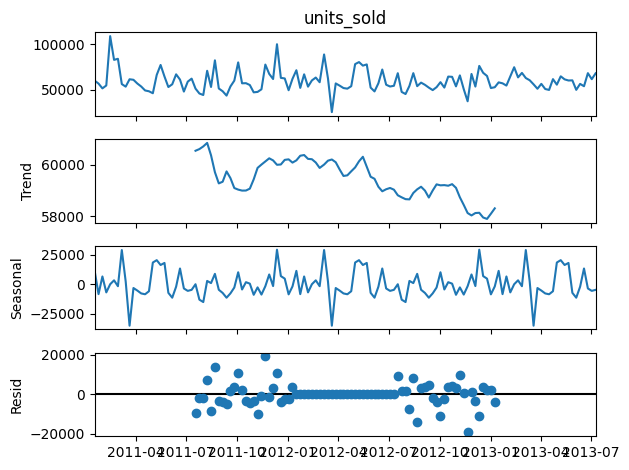

In [8]:
# Set Index
week_data.set_index('week', inplace=True)


# Seasonal Decomposition
seasonal_decompose = sd(week_data['units_sold'], model='Multiplicative', period=52)
seasonal_decompose.plot();

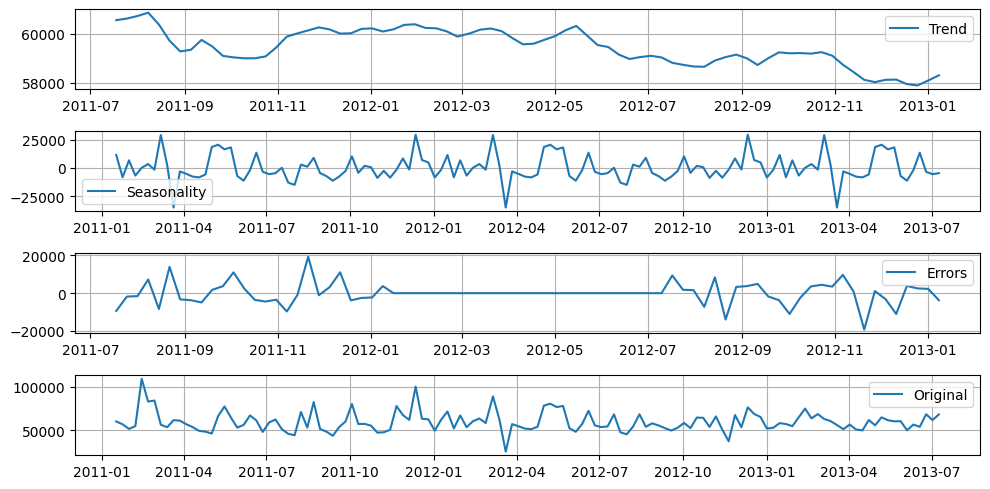

In [9]:
# Seasonal Decomposition(Model = Addictive) And By Subplots
seasonal_decompose = sd(week_data['units_sold'], model='Addictive', period=52)

plt.figure(figsize=(10, 5))

# Trend
plt.subplot(411)
plt.plot(seasonal_decompose.trend, label='Trend')
plt.legend(loc='best')
plt.grid(True)

# Seasonality 
plt.subplot(412)
plt.plot(seasonal_decompose.seasonal, label='Seasonality')
plt.legend(loc='best')
plt.grid(True)

# Errors
plt.subplot(413)
plt.plot(seasonal_decompose.resid, label='Errors')
plt.legend(loc='best')
plt.grid(True)

# Original
plt.subplot(414)
plt.plot(week_data['units_sold'], label='Original')
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()

### 3. Seasnal EDA

In [10]:
# Calculate The Percentage Changes in Unit Sold From one Week to Next
week_data['units_sold_pct_change'] = week_data['units_sold'].pct_change()

# Calculate The Standard Deviation of Percentage Changes
volatility = week_data['units_sold_pct_change'].std()
round(volatility*100, 2)

26.06

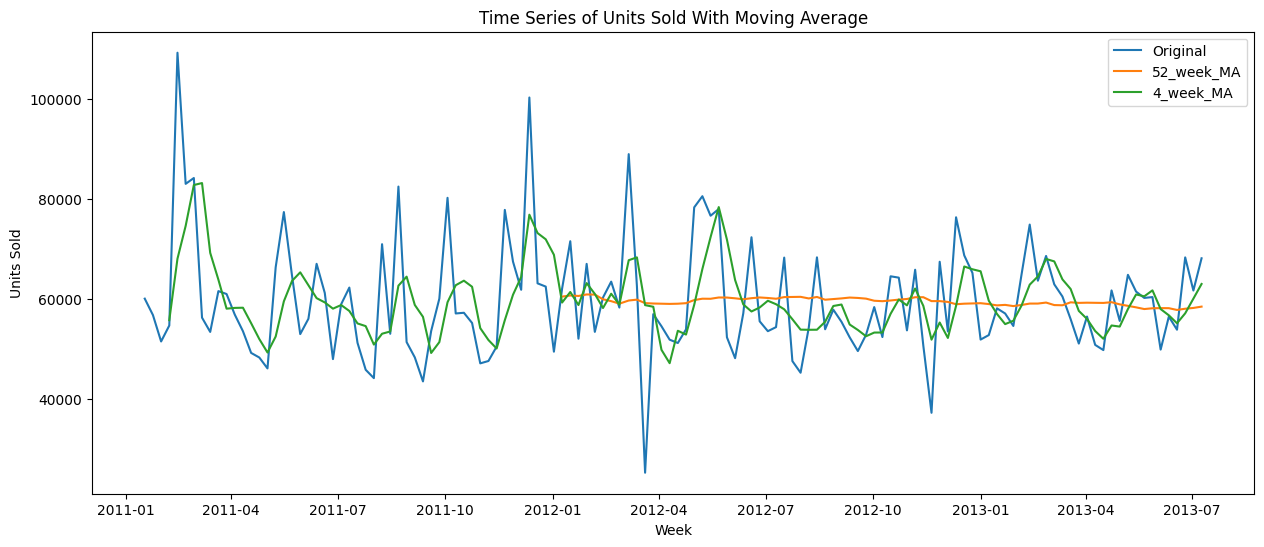

In [11]:
# Calculating 4 week and 52 week Moving Average
week_data['4_week_MA'] = week_data['units_sold'].rolling(window=4).mean()
week_data['52_week_MA'] = week_data['units_sold'].rolling(window=52).mean()

# Plot Movinig
plt.figure(figsize=(15, 6))

plt.plot(week_data['units_sold'], label='Original')
plt.plot(week_data['52_week_MA'], label ='52_week_MA')
plt.plot(week_data['4_week_MA'], label = '4_week_MA')

plt.title('Time Series of Units Sold With Moving Average')
plt.xlabel('Week')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

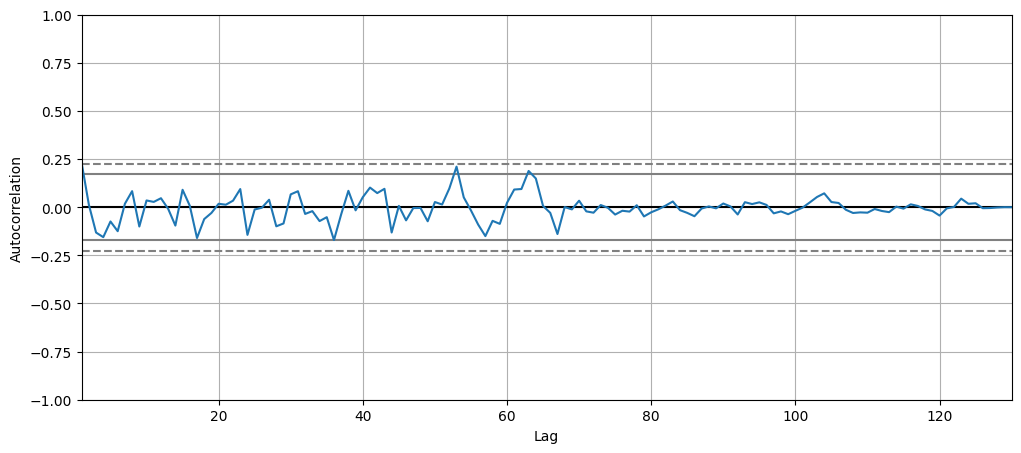

In [12]:
# Plot Auto - Correlation Plot  
plt.figure(figsize=(12, 5))
acp(week_data['units_sold'])
plt.show()

### 4. HaltWinters (Exponential Smoothing)

In [31]:
# Train test split
train_size = int(len(week_data)*0.8)

train_data = week_data['units_sold'][:train_size]
test_data = week_data['units_sold'][train_size:]

# # Holt-Winters
# model = es(train_data, trend='add', seasonal='add', seasonal_periods=52).fit()

# # Resample Data To Weekly Frequency
# week_data_resampled = week_data['units_sold'].resample('W').sum()

# # Split Train And Test data
# train_size = int(len(week_data_resampled)*0.8)
# train_resampled = week_data_resampled[:train_size]
# test_resampled = week_data_resampled[train_size:]

# # Fit Resampled Data To Model
# model_resampled = es(train_resampled, seasonal='add', trend='add', seasonal_periods=52).fit()

resampled_week = week_data['units_sold'].resample('W').sum()
resampled_week
train_size = int(len(week_data)*0.8)

train = resampled_week[:train_size]
test = resampled_week[train_size:]

model = es(train, seasonal='add', trend='add', seasonal_periods=52).fit()
prediction = model.predict(start=test.index[0], end=test.index[-1])

rmse_score = rmse(test, prediction)
print(f'RMSE Score : {rmse_score}')

RMSE Score : 13387.74851201399


#### 4.1 Prediction

RMSE :	 13387.74851201399


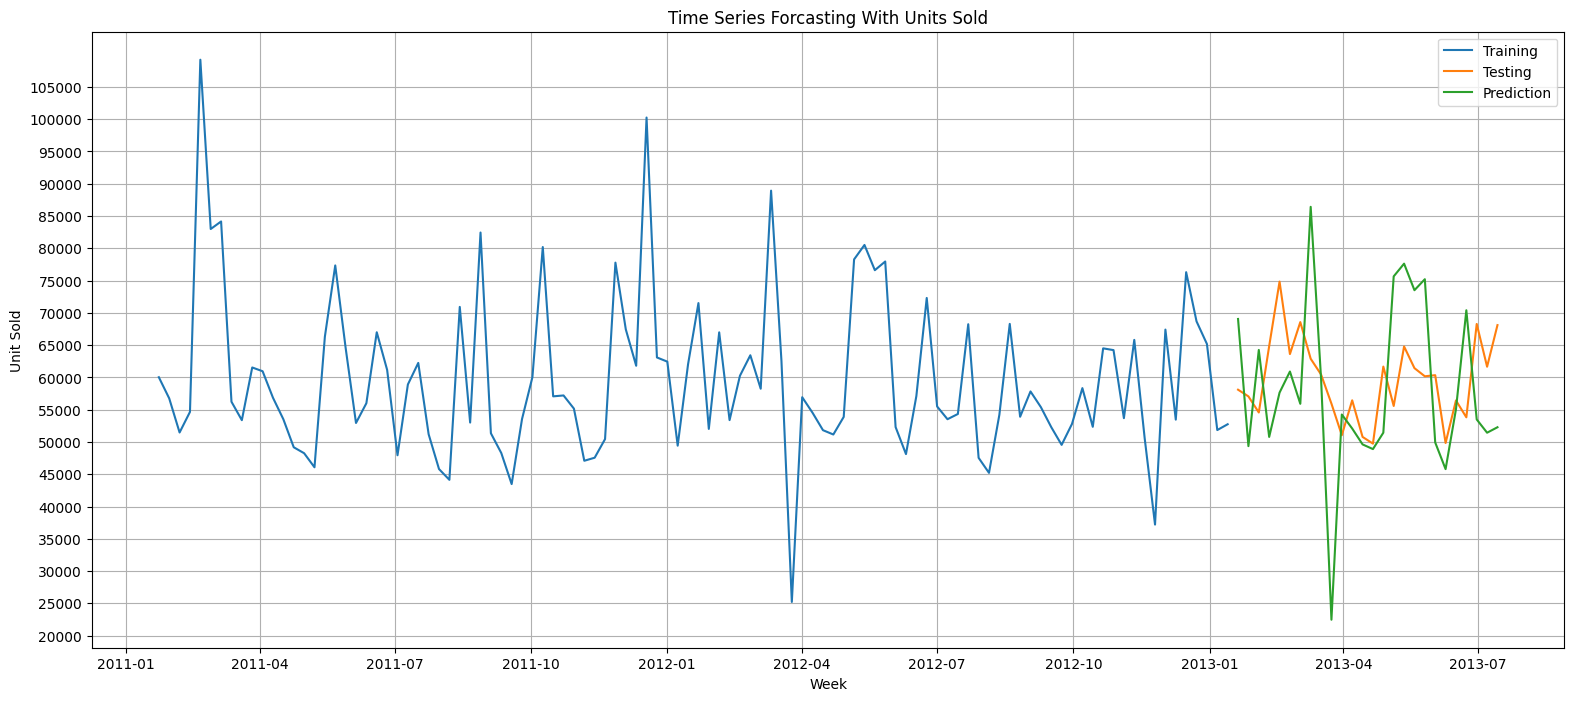

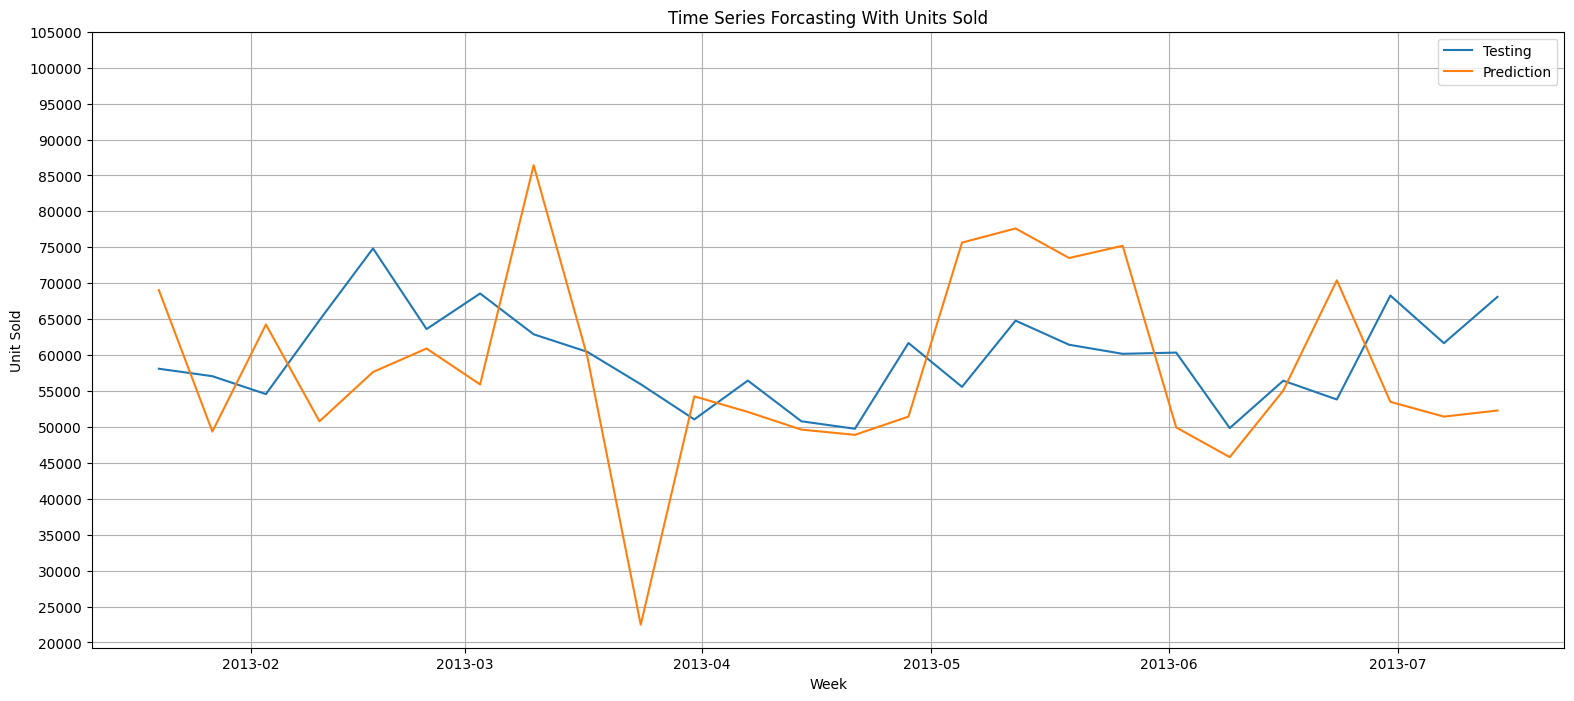

In [14]:
# Generate Prediction On Resampled Data
predicition_resampled = model_resampled.predict(start=test_resampled.index[0], end=test_resampled.index[-1])

# Calculate RMSE On Resampled Data
rmse_resampled = rmse(test_resampled, predicition_resampled)
print('RMSE :\t', rmse_resampled)

# Plot Original Time Series Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(train_resampled, label='Training')
plt.plot(test_resampled, label='Testing')
plt.plot(predicition_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

# Plot Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(test_resampled, label='Testing')
plt.plot(predicition_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

#### 4.2 Forcasting

RMSE :	 13387.74851201399


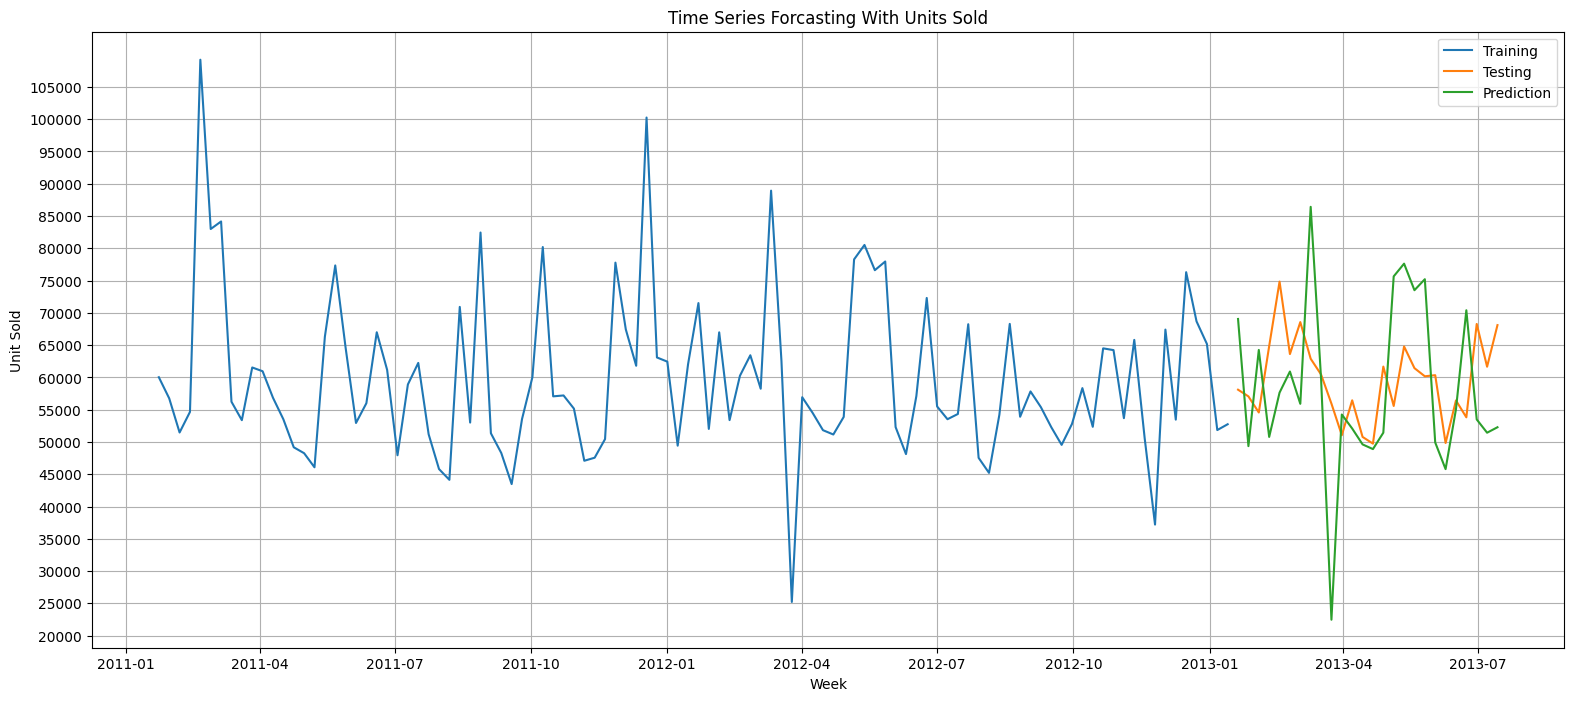

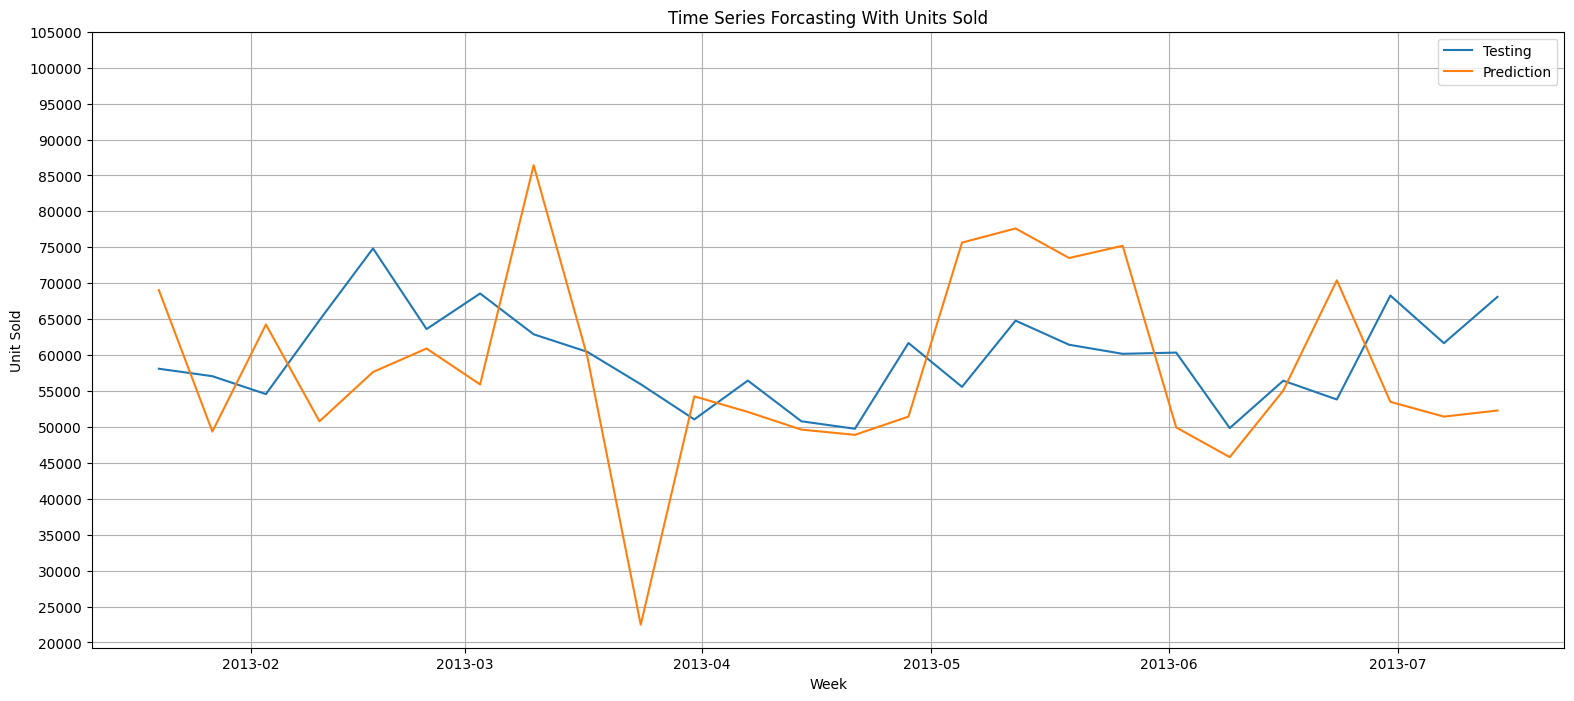

In [15]:
# Generate Prediction On Resampled Data
forcast_resampled = model_resampled.forecast(len(test_resampled))

# Calculate RMSE On Resampled Data
rmse_resampled = rmse(test_resampled, forcast_resampled)
print('RMSE :\t', rmse_resampled)

# Plot Original Time Series Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(train_resampled, label='Training')
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

# Plot Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

#### 4.3 No Trend 

RMSE :	 9297.388619043491


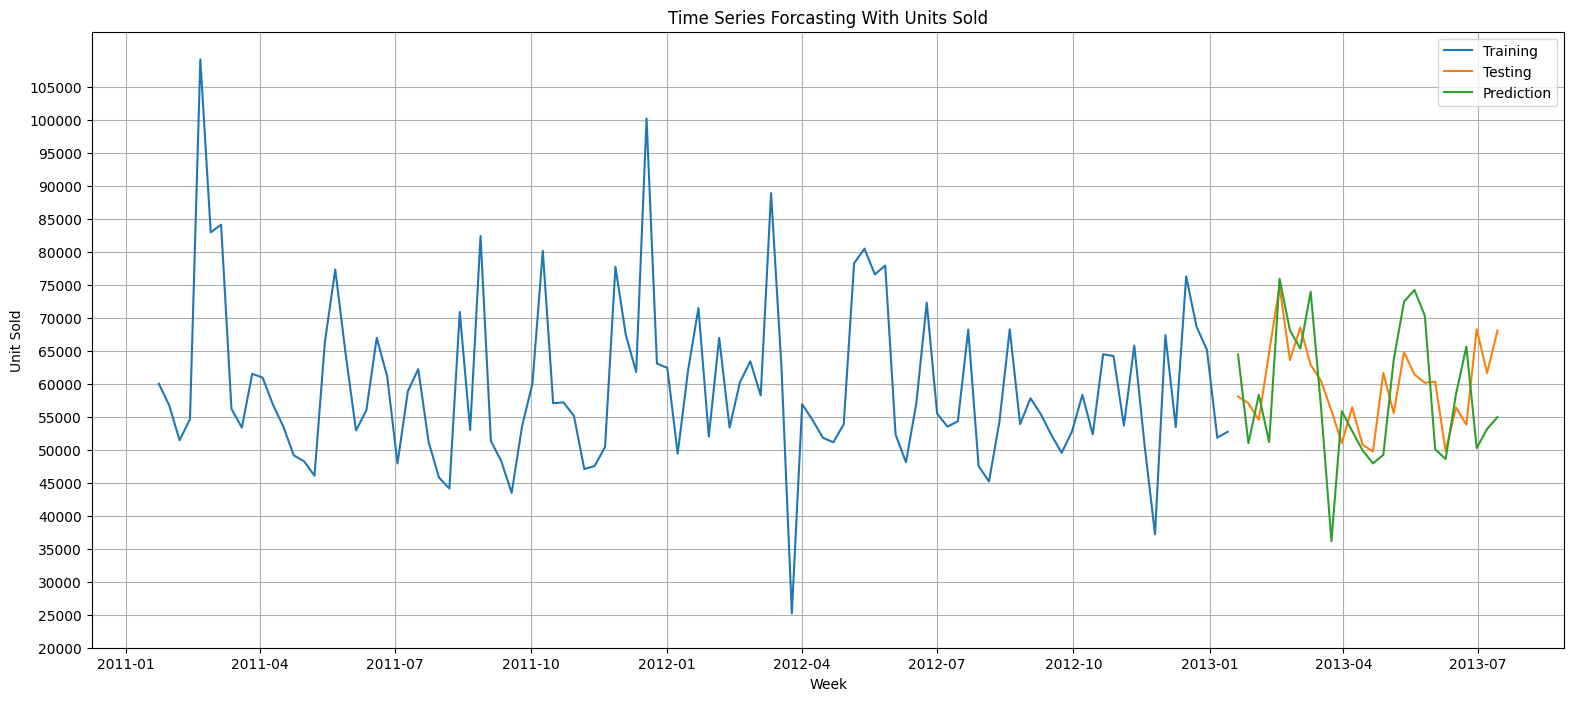

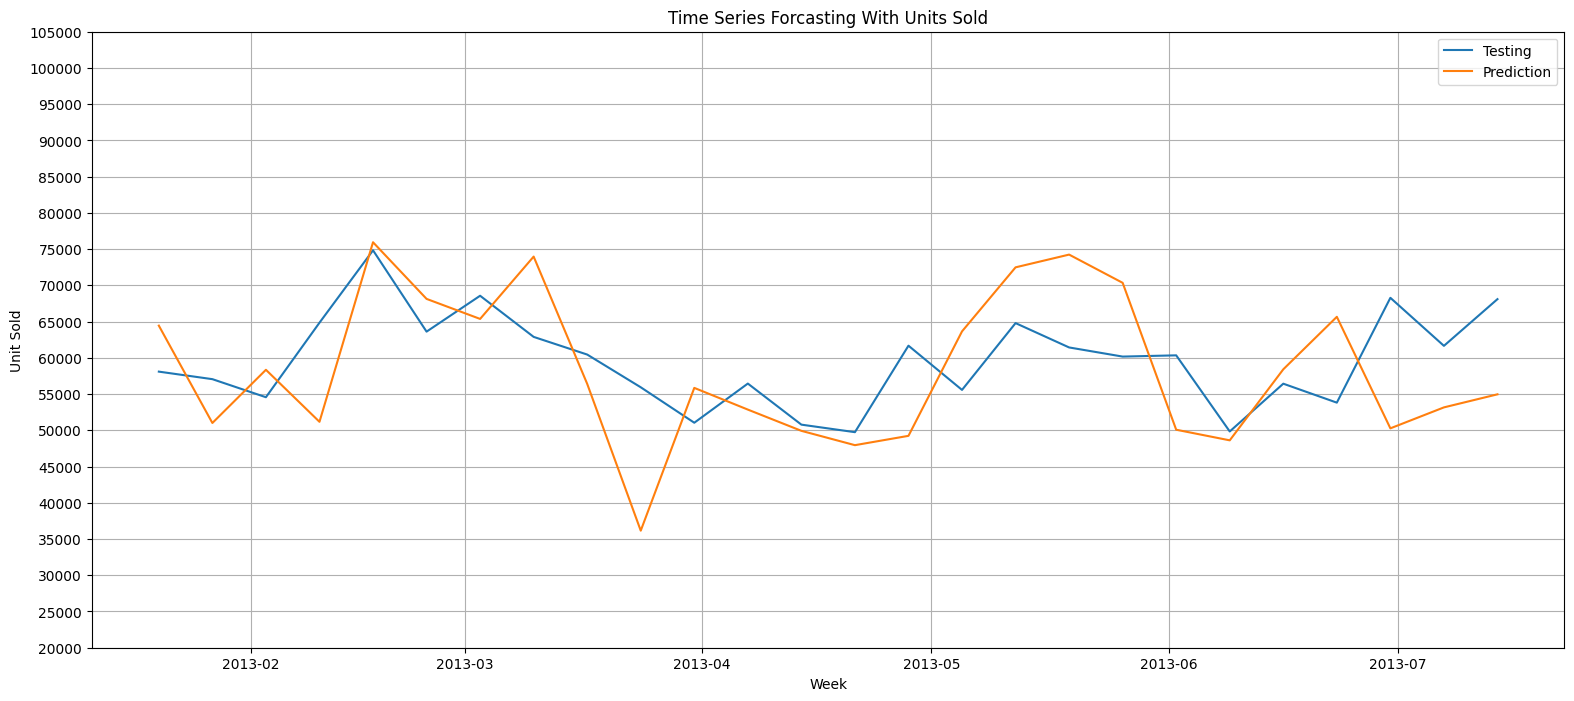

In [16]:
model_resampled = es(train_resampled, seasonal='add', seasonal_periods=52).fit()
# Generate Prediction On Resampled Data
forcast_resampled = model_resampled.forecast(len(test_resampled))

# Calculate RMSE On Resampled Data
rmse_resampled = rmse(test_resampled, forcast_resampled)
print('RMSE :\t', rmse_resampled)

# Plot Original Time Series Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(train_resampled, label='Training')
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

# Plot Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

#### 4.4 No Seasonal

RMSE :	 7616.628959018659


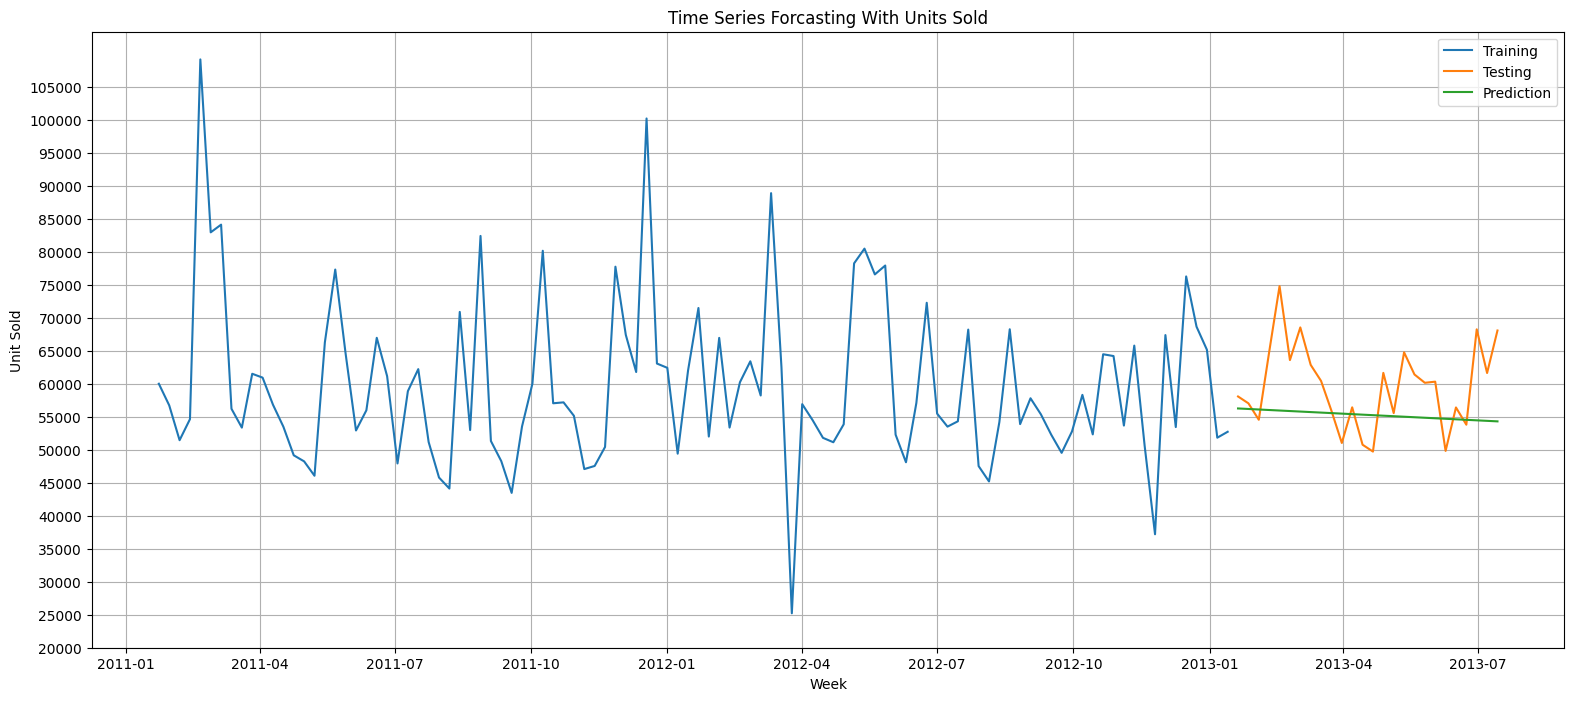

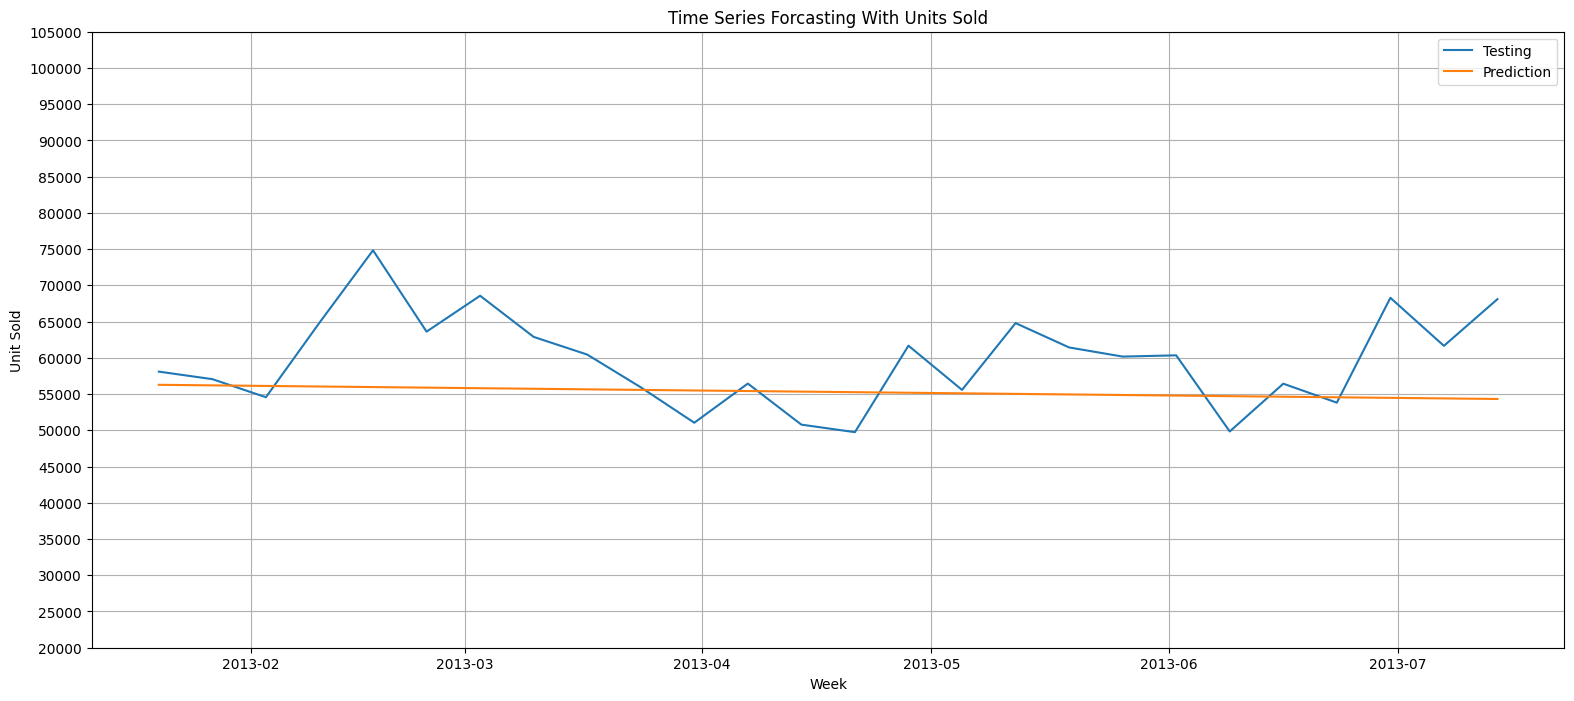

In [17]:
model_resampled = es(train_resampled, trend='add', seasonal_periods=52).fit()
# Generate Prediction On Resampled Data
forcast_resampled = model_resampled.forecast(len(test_resampled))

# Calculate RMSE On Resampled Data
rmse_resampled = rmse(test_resampled, forcast_resampled)
print('RMSE :\t', rmse_resampled)

# Plot Original Time Series Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(train_resampled, label='Training')
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

# Plot Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

#### 4.5 No Seasonal Multiplicative

RMSE :	 6680.650489067091


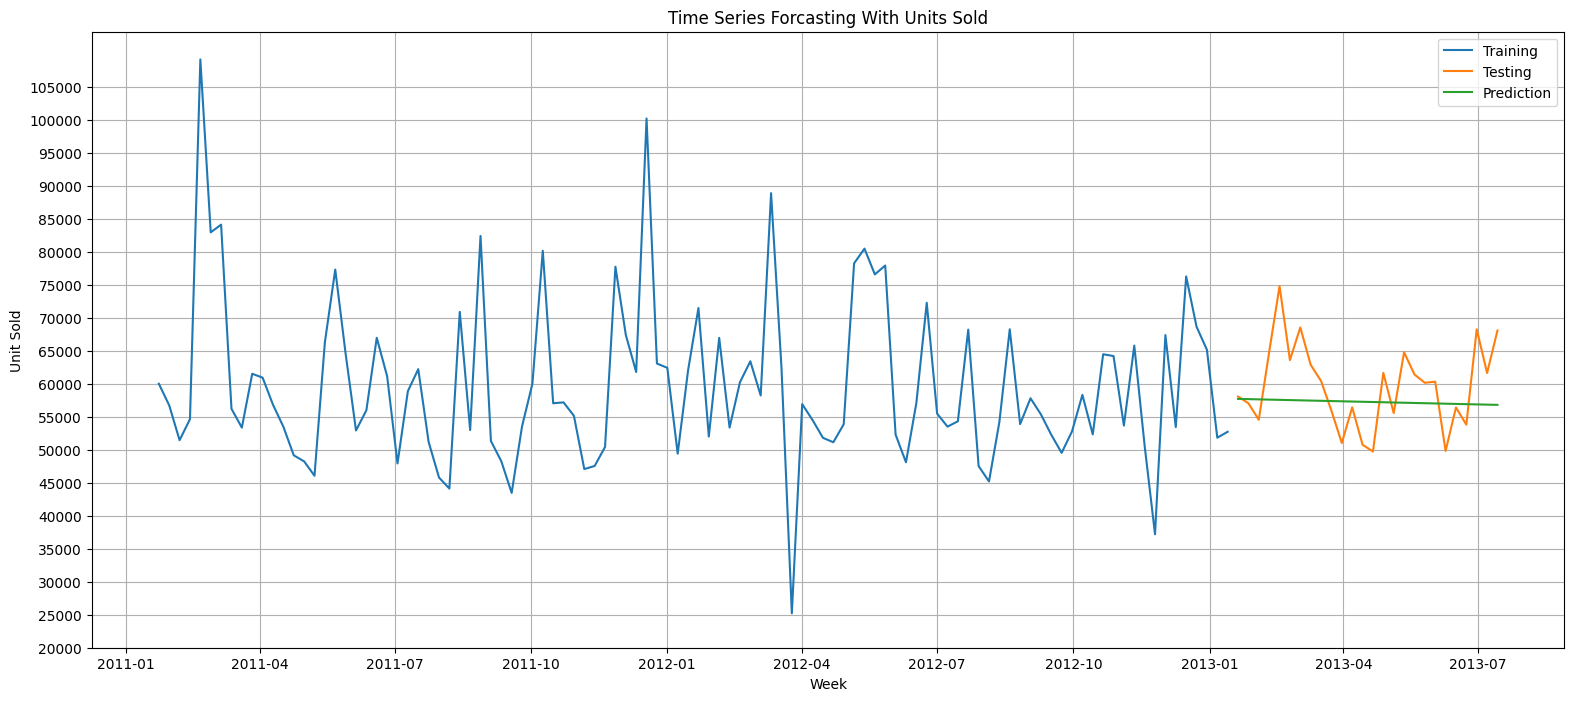

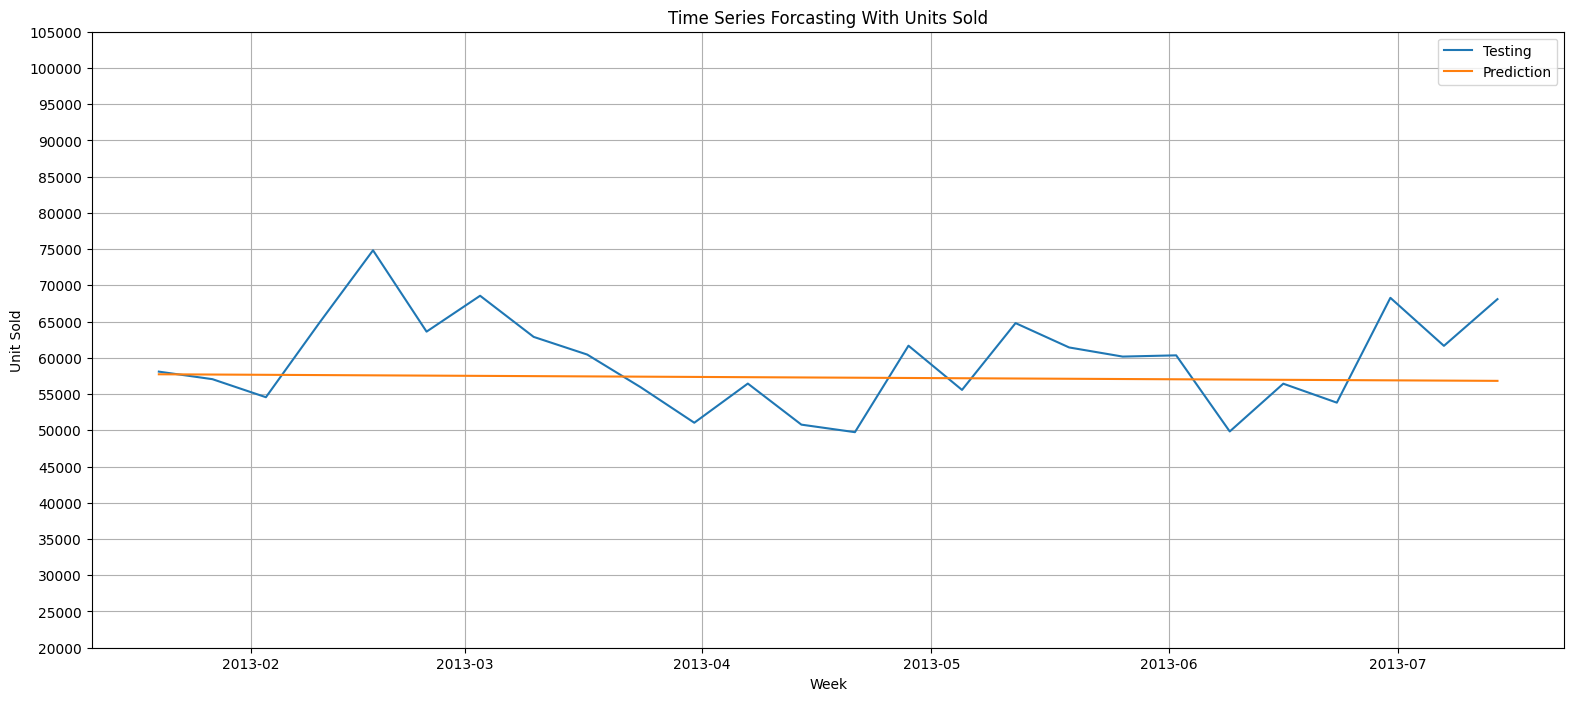

In [18]:
model_resampled = es(train_resampled, trend='mul', seasonal_periods=52).fit()
# Generate Prediction On Resampled Data
forcast_resampled = model_resampled.forecast(len(test_resampled))

# Calculate RMSE On Resampled Data
rmse_resampled = rmse(test_resampled, forcast_resampled)
print('RMSE :\t', rmse_resampled)

# Plot Original Time Series Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(train_resampled, label='Training')
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

# Plot Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

#### 4.6 No Trend Multiplicative

RMSE :	 8736.643152112061


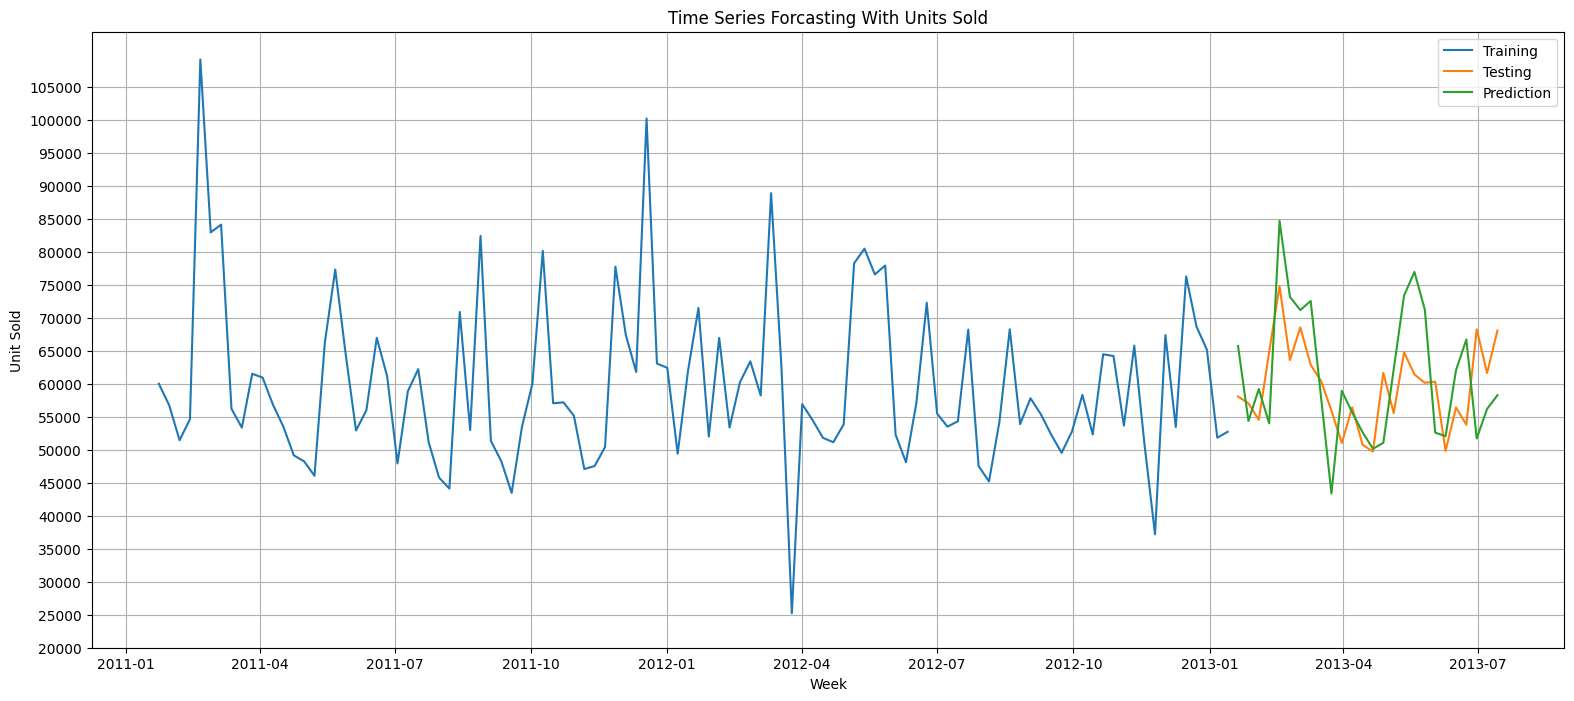

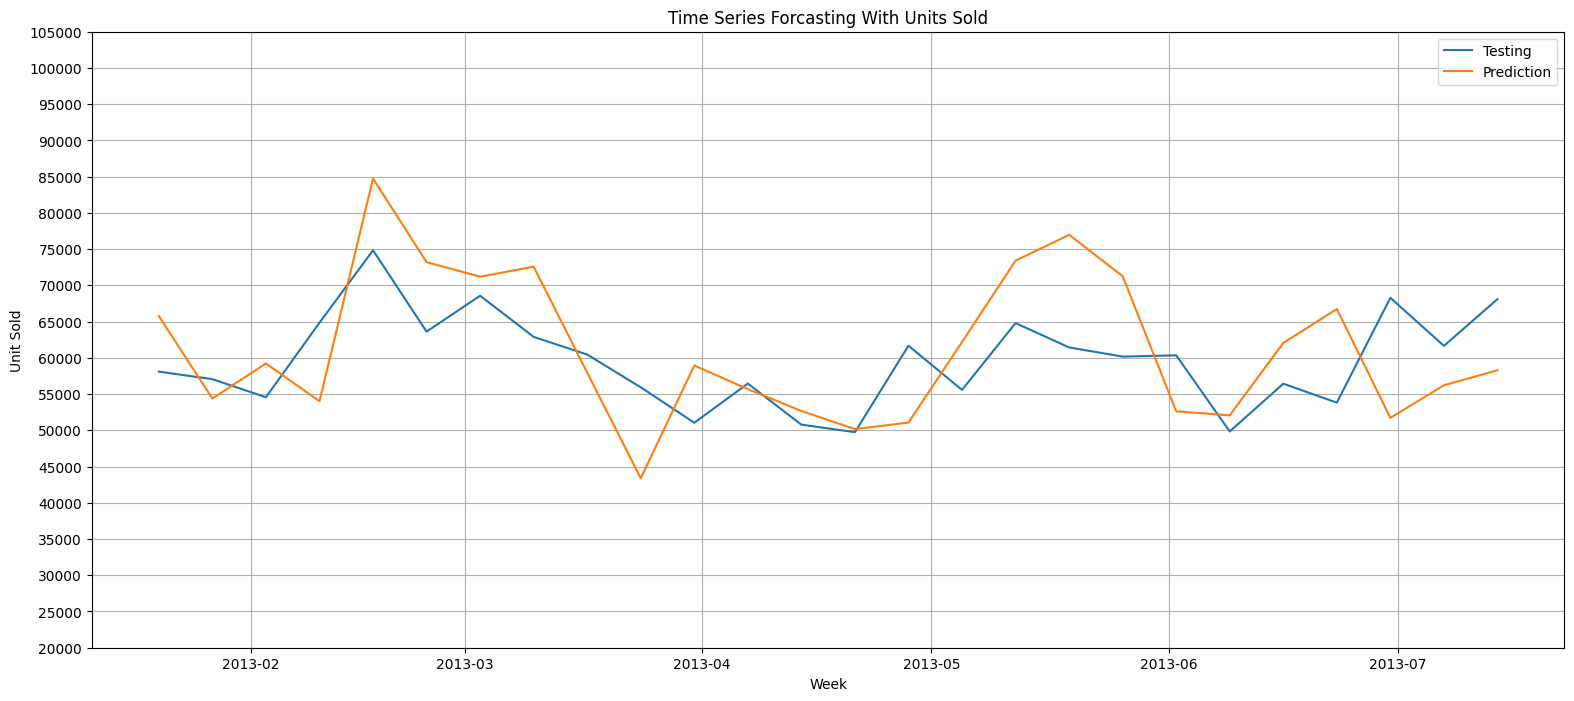

In [19]:
model_resampled = es(train_resampled, seasonal='mul', seasonal_periods=52).fit()
# Generate Prediction On Resampled Data
forcast_resampled = model_resampled.forecast(len(test_resampled))

# Calculate RMSE On Resampled Data
rmse_resampled = rmse(test_resampled, forcast_resampled)
print('RMSE :\t', rmse_resampled)

# Plot Original Time Series Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(train_resampled, label='Training')
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

# Plot Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(test_resampled, label='Testing')
plt.plot(forcast_resampled, label='Prediction')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

### 5. ARIMA

#### 5.1 HPO

In [20]:
train_resampled

week
2011-01-23     60029
2011-01-30     56752
2011-02-06     51467
2011-02-13     54656
2011-02-20    109207
               ...  
2012-12-16     76298
2012-12-23     68679
2012-12-30     65181
2013-01-06     51847
2013-01-13     52745
Freq: W-SUN, Name: units_sold, Length: 104, dtype: int64

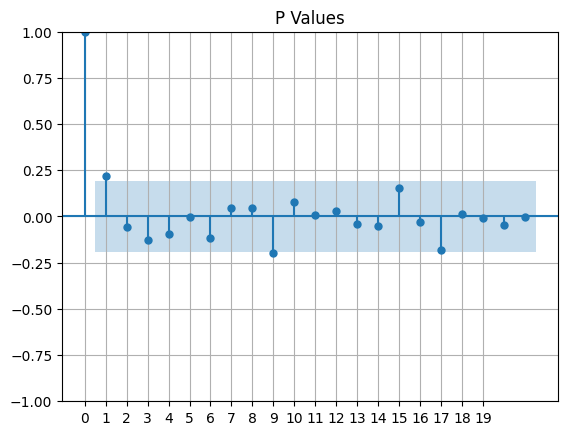

D : 0


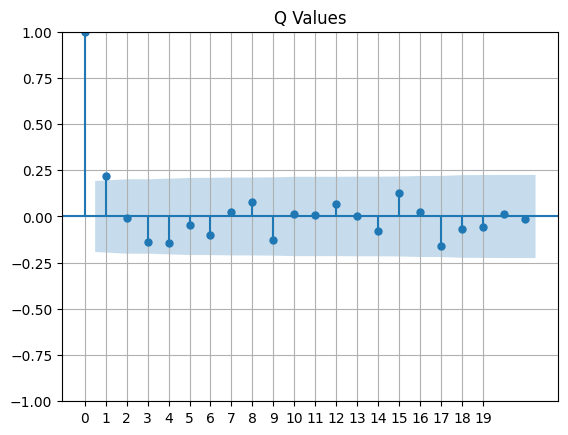

(2256.5307317210973, (2, 0, 1))
<function root_mean_squared_error at 0x00000292C79D7BA0> (2, 0, 1)


In [21]:
# P Values
pacf(train_resampled)
plt.grid()
plt.title('P Values')
plt.xticks(np.arange(0,20))
plt.show();

# D Values
adf_for_d = adf(train_resampled)[1]
if adf_for_d < 0.05:
    print('D : 0')
else:
    print('D Not 0 \nAdf Result :', d_value_by_adf)

# Q Values
acf(train_resampled)
plt.grid()
plt.title('Q Values')
plt.xticks(np.arange(0,20))
plt.show();

# HPO Implimentation
p_values = [0, 1, 2]
d_values = [0]
q_values = [0, 1]

rmse_worst, best_order = np.inf, None

for p in p_values:
    for d in d_values:
        for q in q_values:
            
            History = [x for x in train_resampled.values]
            predictions = []
            AIC = []
            order = (p, d, q)
            for t in range(len(test_resampled)):
                model = ARIMA(History, order=order)
                model_fit = model.fit()
                prediction = model_fit.forecast()[0]

                predictions.append(prediction)
                AIC.append((model_fit.aic, order))

            rmse_score = rmse(test_resampled.values, predictions)
            if rmse_score < rmse_worst:
                rmse = rmse
                best_order = order
    
print(sorted(AIC)[0])
print(rmse, order)
        

#### 5.2 Model Implementation And Forecasting

In [22]:
# Model Implimentation
modle = ARIMA(train_resampled, order=(2, 0, 1))
model_fit = model.fit()

# Forecasting
forecaste = model_fit.forecast(steps=len(test_resampled))

# RMSE
rmse_score_arima = rmse(test_resampled, forecaste)
print('Rmse Score Arima :', rmse_score_arima)

Rmse Score Arima : 6227.520839008923


#### 5.3 Plot Prediction

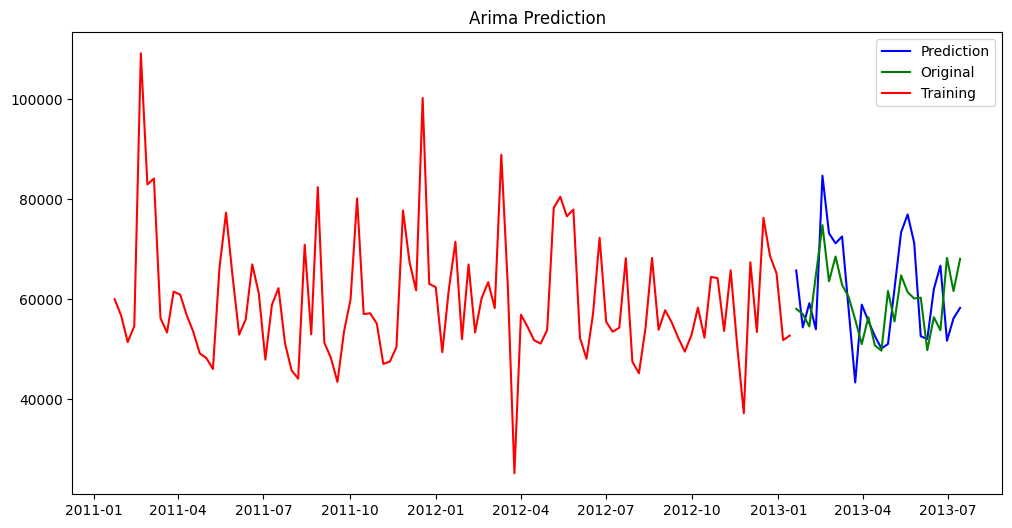

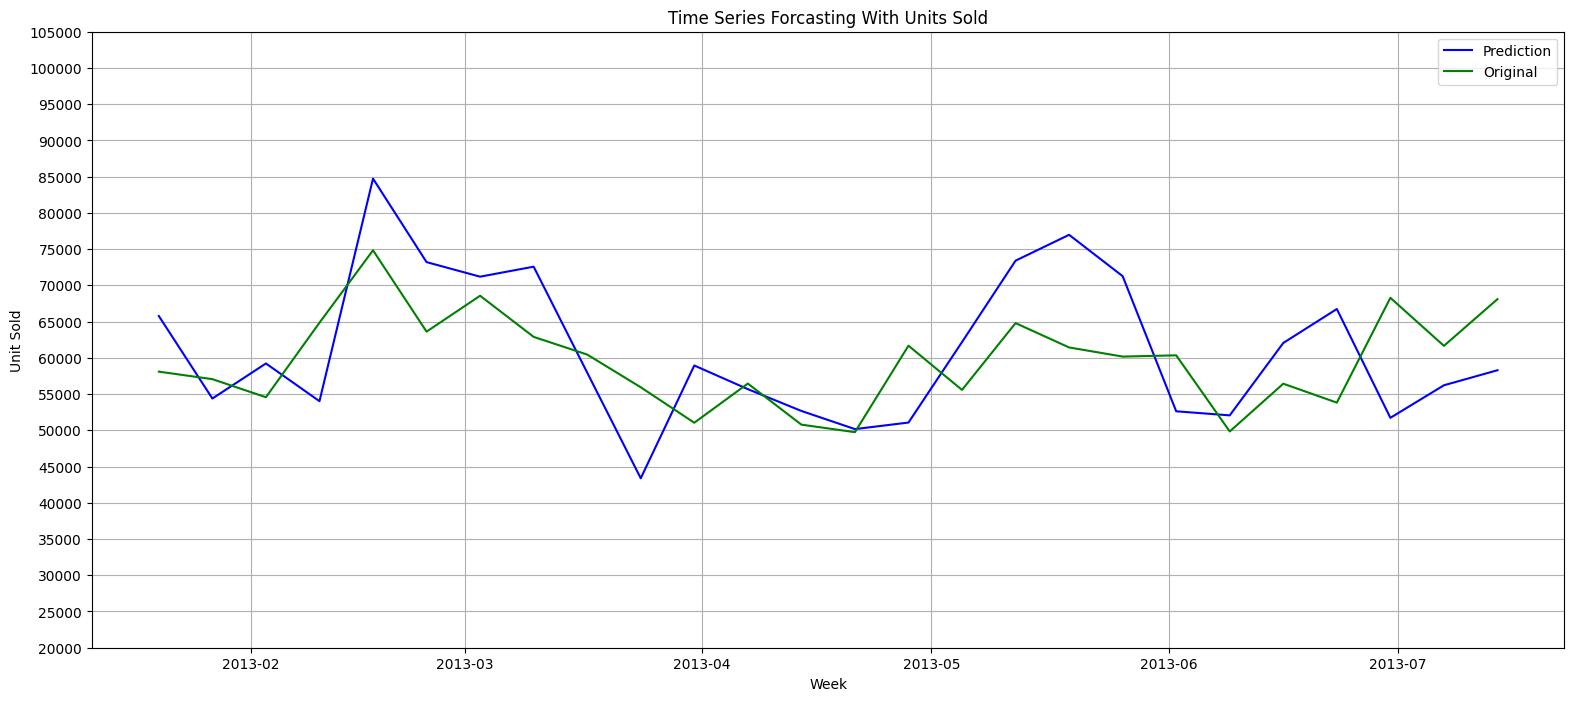

In [23]:
# Plot Testing,Forcasting and Training Values

plt.figure(figsize=(12, 6))
plt.plot(forcast_resampled, label='Prediction', color='blue')
plt.plot(test_resampled, label='Original', color='green')
plt.plot(train_resampled, label='Training', color='red')
plt.legend()
plt.title('Arima Prediction')
plt.show()

# Plot Testing And Forcasting Values
plt.figure(figsize=(19, 8))
plt.plot(forcast_resampled, label='Prediction', color='blue')
plt.plot(test_resampled, label='Original', color='green')
plt.xlabel('Week')
plt.ylabel('Unit Sold')
plt.title('Time Series Forcasting With Units Sold')
plt.legend(loc='best')
plt.grid()
plt.yticks(np.arange(20000, 110000, 5000))
plt.show()

### 6. Facebook Prophet

#### 6.1 Model Implimentation

22:27:13 - cmdstanpy - INFO - Chain [1] start processing
22:27:13 - cmdstanpy - INFO - Chain [1] done processing


RMSE Score Of Facebook Prophet : 7713.58560491526


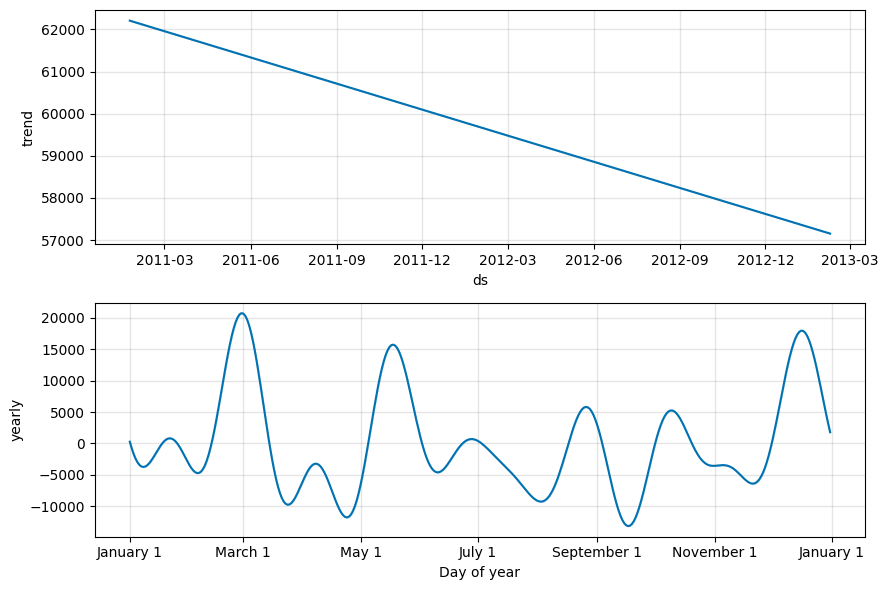

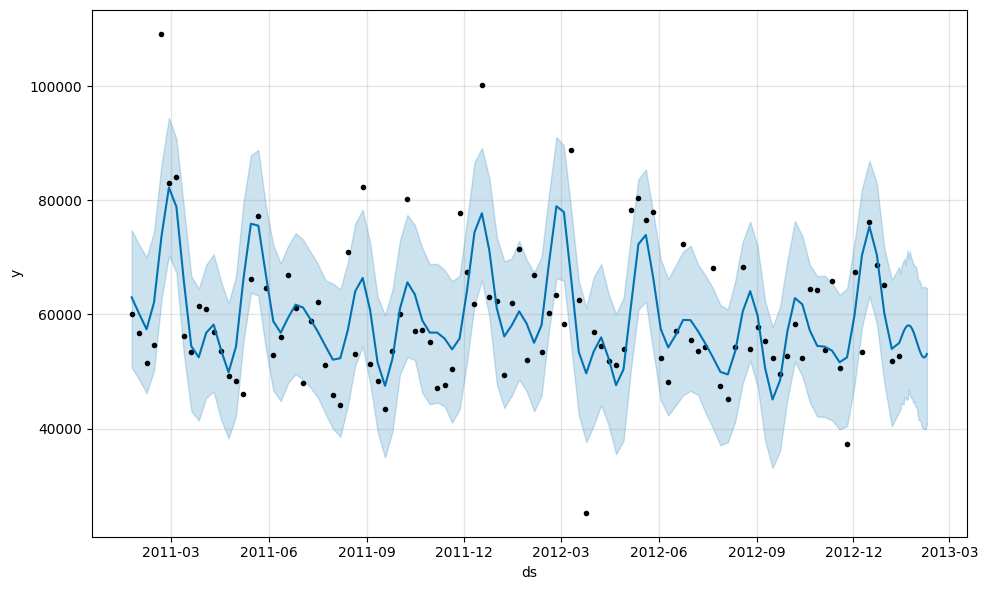

In [25]:
# Prophet Prerequists
train_resampled = train_resampled.reset_index()
train_resampled = train_resampled.rename(columns={'week':'ds', 'units_sold':'y'})
model = Prophet(yearly_seasonality=True)
model_fit = model.fit(train_resampled)

future_data = model_fit.make_future_dataframe(periods=len(test_resampled))
prediction = model.predict(future_data)

# RMSE
rmse_score = rmse(test_resampled.values, prediction['yhat'][-len(test_resampled):])
print(f'RMSE Score Of Facebook Prophet : {rmse_score}')
# Plot Components
model.plot_components(prediction);

# Plot Data Predictoin
model.plot(prediction);

#### 6.2 Plot Graph By Plotly

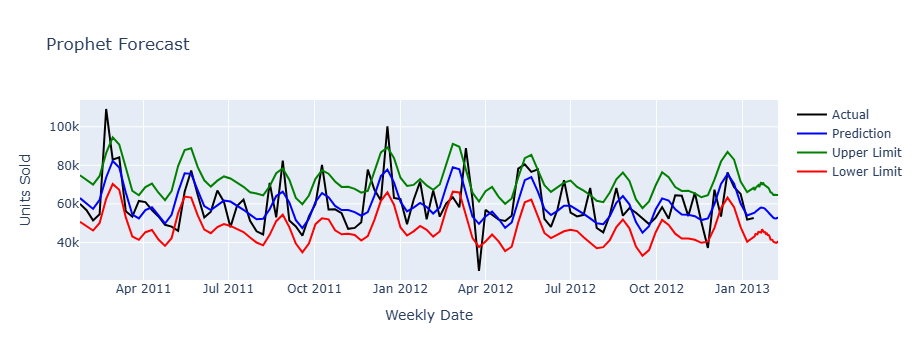

In [36]:
actual = go.Scatter(x=train_resampled['ds'], y=train_resampled['y'], name='Actual', line=dict(color='black'))
predicton = go.Scatter(x=prediction['ds'], y=prediction['yhat'], name='Prediction', line=dict(color='blue'))
upper_limit = go.Scatter(x=prediction['ds'], y=prediction['yhat_upper'], name='Upper Limit', line=dict(color='green'))
lower_limit = go.Scatter(x=prediction['ds'], y=prediction['yhat_lower'], name='Lower Limit', line=dict(color='red'))

fig = go.Figure([actual, predicton, upper_limit, lower_limit])

fig.update_layout(
    title='Prophet Forecast',
    xaxis_title='Weekly Date',
    yaxis_title='Units Sold')
    
                  

fig.show();
py.plot([actual, predicton, upper_limit, lower_limit]);


### 7. Vector AutoRegression

VAR RMSE: 79.4797346142731


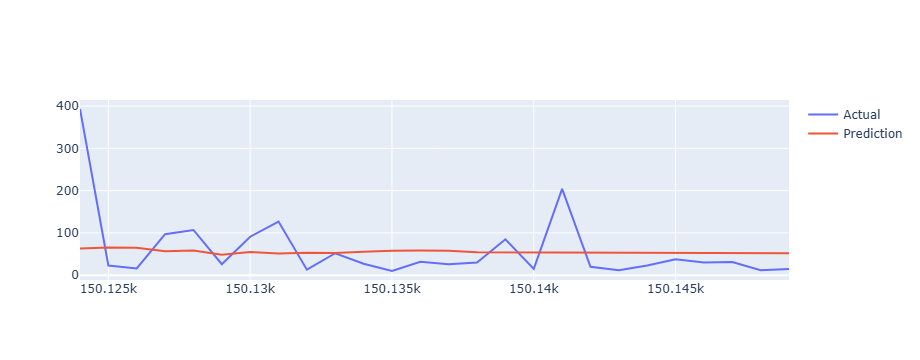

In [40]:
# Data
var_data = df[['units_sold','total_price','is_display_sku']]
var_data = var_data.dropna()

# Split In Training And Testing
train = var_data[:-26]
test = var_data[-26:]

# Model Initilization
model = VAR(train)

# Fitting The Model
model_fit = model.fit()
model_fit = model.fit(maxlags=1 5, ic='aic')
lag_order = model_fit.k_ar

# Forecast
forecast_input = train.values[-lag_order:]
forecast = model_fit.forecast(y=forecast_input, steps=len(test))
forecast_df = pd.DataFrame(
    forecast,
    index=test.index,
    columns=test.columns
)

rmse_score = rmse(
    test['units_sold'],
    forecast_df['units_sold']
)

print("VAR RMSE:", rmse_score)
import plotly.graph_objects as go

actual = go.Scatter(
    x=test.index,
    y=test['units_sold'],
    name='Actual'
)

prediction = go.Scatter(
    x=forecast_df.index,
    y=forecast_df['units_sold'],
    name='Prediction'
)

fig = go.Figure([actual, prediction])
fig.show()